<a href="https://colab.research.google.com/github/DananjayaChathuranga/ML_Group6_CW1/blob/main/CI7521_CW1_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Coursework 1 Group 06

Group number: 6

Student names and k-numbers:
1. K2635998 - Dananjaya Chathuranga
2. ...
3. K2635944 - Sadeep Sachintha

# Load modules (code)

In [ ]:
# add code for loading modules - Done by Dananjaya K2635998
from sklearn.datasets import fetch_openml
dataset = fetch_openml(data_id=4538, as_frame=False)

print("Keys in dataset:", dataset.keys())

Keys in dataset: dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])


# Load data (code)

In [ ]:
# add code for loading data - Done by Dananjaya K2635998
from sklearn.datasets import fetch_openml
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load the GesturePhoaseSEgmentationprocessed dataset (ID: 4538) - Done by Dananjaya K2635998
dataset = fetch_openml(data_id=4538, as_frame=False)

X = dataset.data
# Use LabelEncoder to convert categorical target labels to integers
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(dataset.target)

print("Shape X", X.shape)
print("Labels shape", y.shape)
print("Original target classes -", label_encoder.classes_)
print("encoded lables -", np.unique(y))
print("Encoded target labels (first 5):\n - ", y[:5])


#train/test split (70%/30%)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)

print("Shape X train raw -", X_train_raw.shape)
print("Shape X test raw -", X_test_raw.shape)


#Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

#Dimenstionality Reduction (PCA) - using 95% variance
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original dimensions -", X.shape[1])
print("Reduced dimensions (PCA) - ", X_train_pca.shape[1])

#_____________________________________________________________________________________END_Dananjaya______________________________________________________

Shape X (9873, 32)
Labels shape (9873,)
Original target classes - ['D' 'H' 'P' 'R' 'S']
encoded lables - [0 1 2 3 4]
Encoded target labels (first 5):
 -  [0 0 0 0 0]
Shape X train raw - (6911, 32)
Shape X test raw - (2962, 32)
Original dimensions - 32
Reduced dimensions (PCA) -  20


# Classification

## Classification methods used (text)

Mention the classification methods used below. You should not describe them, but if they have not been discussed in the class, you should cite the source:


1.   Logistic Regression - K2635998
2.   Support Vector Machine - svm - K2635998
3.   Random Forest -
4.   K-Nearest Neighbors
5.
6.
7.
8.



## Training (code)

In [ ]:
#add code for training
#___________________________________________________________________START_Dananjaya_______________________________________________
# Done by Dananjaya from this point

#logistic regression (no PCA)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


log_reg_params = {
    "C": [0.01, 0.1, 1, 10],
    "penalty": ["l2"],
    "solver": ["liblinear"],
    "max_iter": [300]
}

log_reg_grid = GridSearchCV(
    LogisticRegression(),
    log_reg_params,
    scoring="balanced_accuracy",
    cv=5,
    n_jobs=-1
)

log_reg_grid.fit(X_train_scaled, y_train)
log_reg_best = log_reg_grid.best_estimator_

print("Best parameters for Logistic Regression with no PCA -", log_reg_grid.best_params_)


#logistic regression (with PCA)
log_reg_pca = GridSearchCV (
    LogisticRegression(),
    log_reg_params,
    scoring="balanced_accuracy",
    cv=5,
    n_jobs=-1
)

log_reg_pca.fit(X_train_pca, y_train)
log_reg_best_pca = log_reg_pca.best_estimator_

print("Best parameters for Logistic Regression with PCA -", log_reg_pca.best_params_)


#Support Vector Machine (No PCA)
from sklearn.svm import SVC

svm_params = {
    "C": [0.1, 1, 10],
    "kernel": ["rbf"],
    "gamma": ["scale", "auto"]
}

svm_grid = GridSearchCV(
    SVC(probability=True),
    svm_params,
    scoring="balanced_accuracy",
    cv=5,
    n_jobs=-1
)

svm_grid.fit(X_train_scaled, y_train)
svm_best = svm_grid.best_estimator_

print("Best parameters for SVM with no PCA -", svm_grid.best_params_)


#Support Vector Machine (with PCA)
svm_grid_pca = GridSearchCV(
    SVC(probability=True),
    svm_params,
    scoring="balanced_accuracy",
    cv=5,
    n_jobs=-1
)

svm_grid_pca.fit(X_train_pca, y_train)
svm_best_pca = svm_grid_pca.best_estimator_

print("Best parameters for SVM with PCA -", svm_grid_pca.best_params_)

#_______________________________________________________________________End_Dananjaya____________________________________________________________________

Best parameters for Logistic Regression with no PCA - {'C': 10, 'max_iter': 300, 'penalty': 'l2', 'solver': 'liblinear'}
Best parameters for Logistic Regression with PCA - {'C': 1, 'max_iter': 300, 'penalty': 'l2', 'solver': 'liblinear'}
Best parameters for SVM with no PCA - {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best parameters for SVM with PCA - {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}


## Evaluation (code)

{'LR': {'Balanced Accuracy': np.float64(0.3518490457556573), 'Macro AUC': np.float64(0.7569180219220417), 'Micro AUC': np.float64(0.7839248760236004)}, 'LR_PCA': {'Balanced Accuracy': np.float64(0.34625362259623593), 'Macro AUC': np.float64(0.7456269852619826), 'Micro AUC': np.float64(0.7785956974250932)}, 'SVM': {'Balanced Accuracy': np.float64(0.4692792914940159), 'Macro AUC': np.float64(0.8086638691170442), 'Micro AUC': np.float64(0.8334889069788329)}, 'SVM_PCA': {'Balanced Accuracy': np.float64(0.46439195400673167), 'Macro AUC': np.float64(0.800547537693739), 'Micro AUC': np.float64(0.8292018504933751)}}


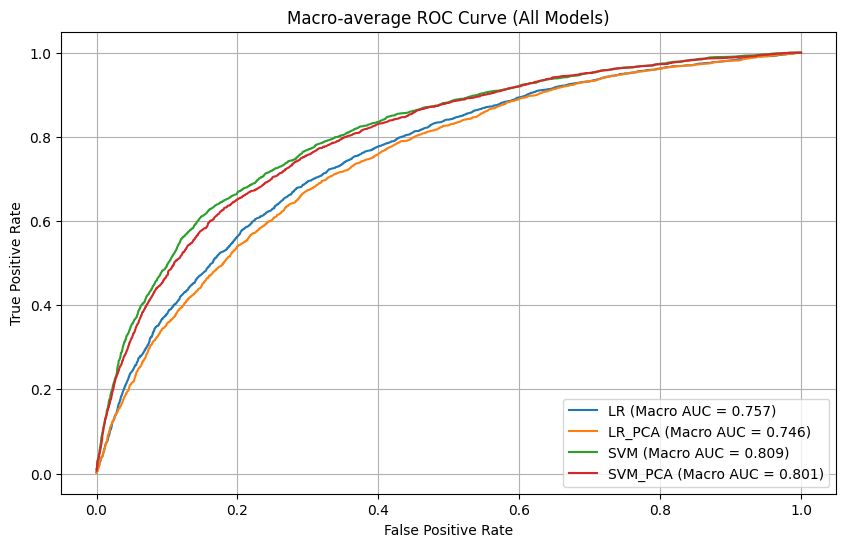

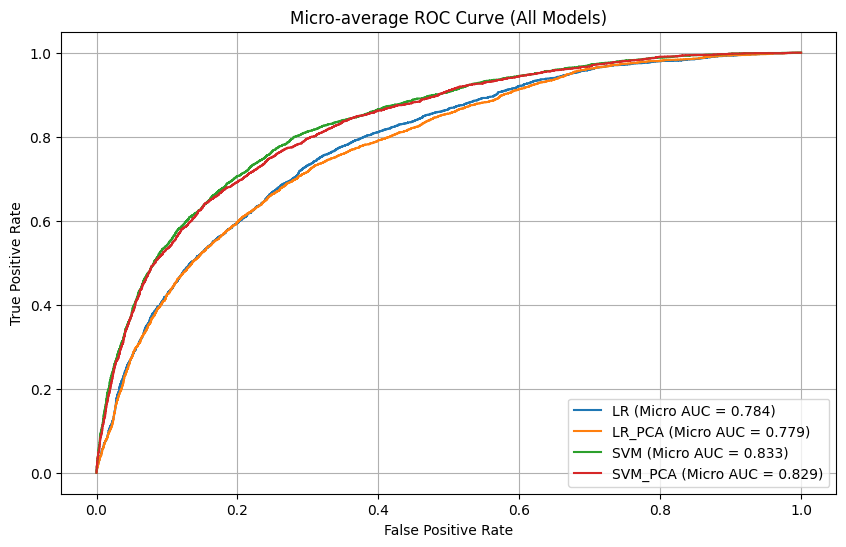

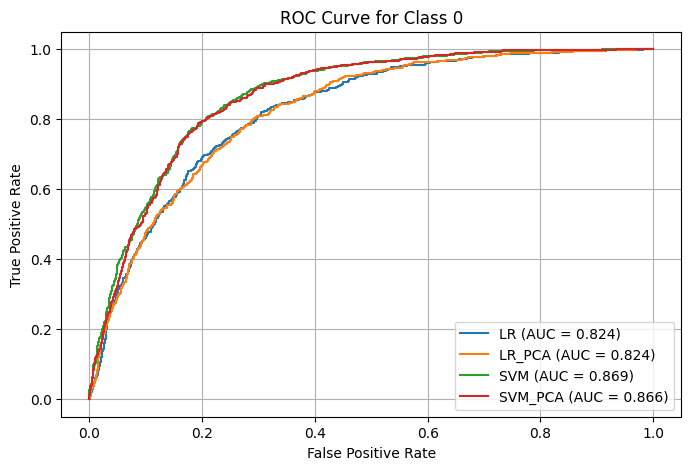

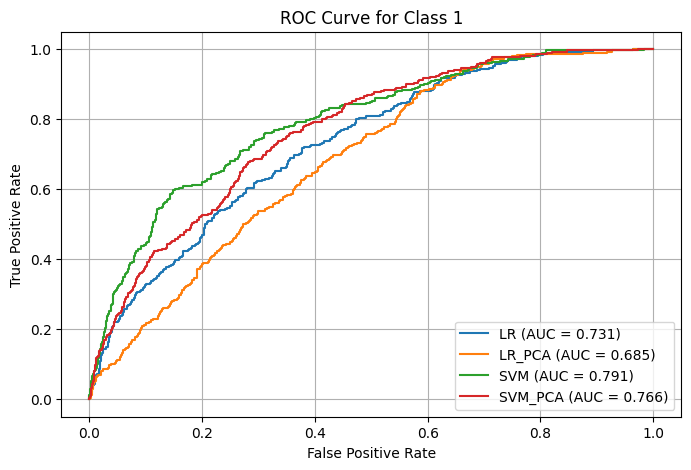

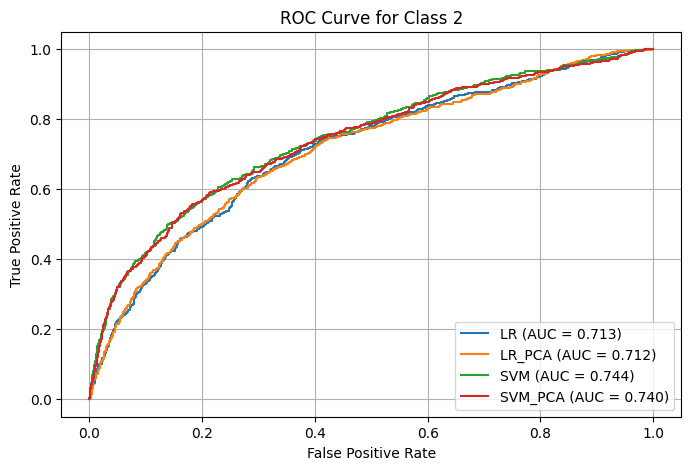

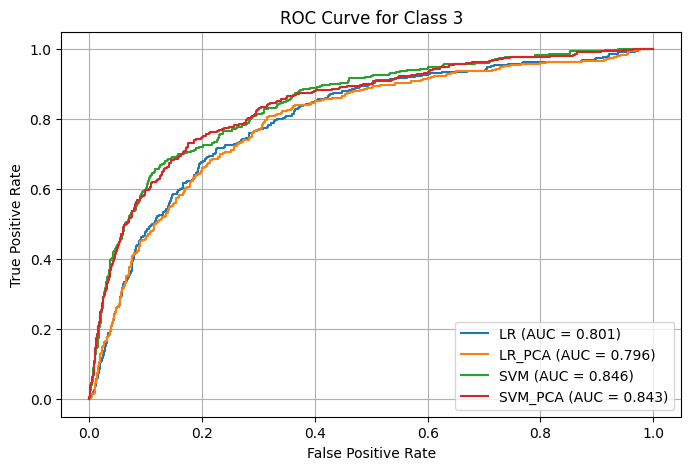

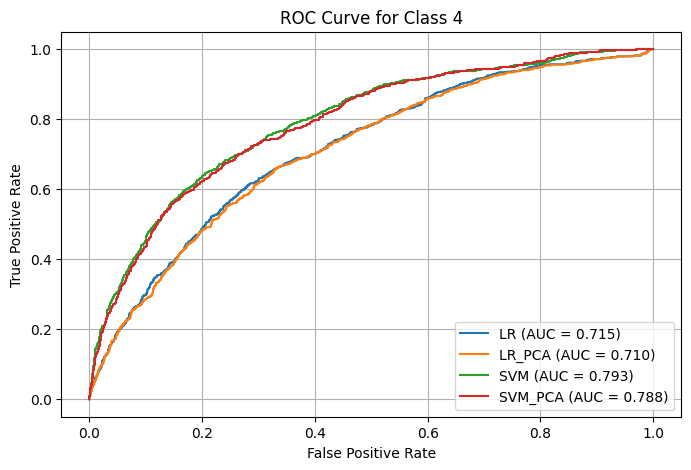

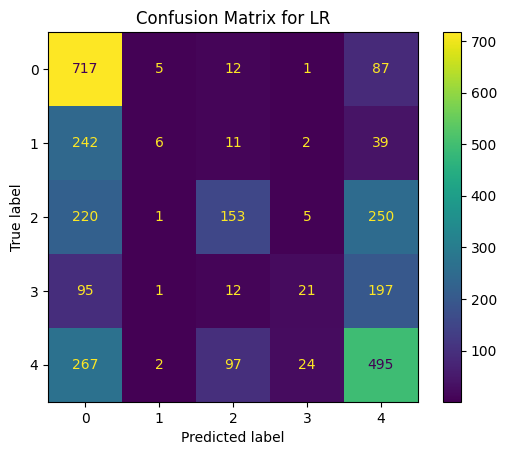

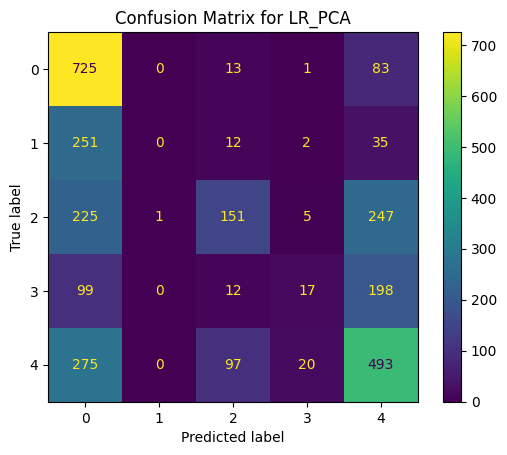

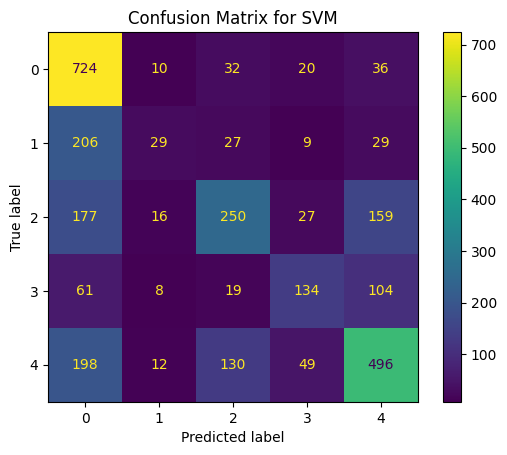

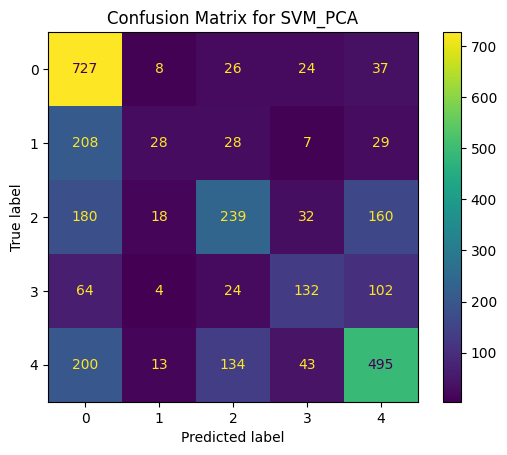

In [ ]:
#add code for evaluation
#______________________________________________________________START_Dananjaya____________________________________________________________

from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import LabelEncoder
import numpy as np
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay

models = {
    "LR" : log_reg_best,
    "LR_PCA" : log_reg_best_pca,
    "SVM" : svm_best,
    "SVM_PCA" : svm_best_pca
}

results = {}

for name, model in models.items():
    if "PCA" in name:
        X_use = X_test_pca
    else:
        X_use = X_test_scaled

    #preds = model.predict(X_test_scaled if "PCA" not in name else X_test_pca)
    #probs = model.predict_proba(X_test_scaled if "PCA" not in name else X_test_pca)

    ##Predinctions and probability
    preds = model.predict(X_use)
    probs = model.predict_proba(X_use)

    #metrics
    bal_acc = balanced_accuracy_score(y_test, preds)
    macro_auc = roc_auc_score(y_test, probs, multi_class="ovr", average="macro")
    micro_auc = roc_auc_score(y_test, probs, multi_class="ovr", average="micro")

    results[name] = {
        "Balanced Accuracy" : bal_acc,
        "Macro AUC" : macro_auc,
        "Micro AUC" : micro_auc
    }
print(results)




#ROC curcves (MACRO, MICRO & PRE CLASS)
#One vs rest Binarized Targets

classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]


# Macro-average ROC Curves for all methods (Plot all on one figure)
plt.figure(figsize=(10, 6))
for name, model in models.items():
  if "PCA" in name:
    X_use = X_test_pca
  else:
    X_use = X_test_scaled

  probs = model.predict_proba(X_use)
  fpr = dict()
  tpr = dict()

  for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], probs[:, i])

  # Compute macro-average for the current model
  all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
  mean_tpr = np.zeros_like(all_fpr)

  for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

  mean_tpr /= n_classes
  macro_auc_model = auc(all_fpr, mean_tpr)

  plt.plot(all_fpr, mean_tpr, label = f"{name} (Macro AUC = {macro_auc_model:.3f})")

plt.title("Macro-average ROC Curve (All Models)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid()
plt.show()


# Micro-average ROC curves for all methods (Plot all on one figure)
plt.figure(figsize=(10, 6))
for name, model in models.items():
  if "PCA" in name:
    X_use = X_test_pca
  else:
    X_use = X_test_scaled

  probs = model.predict_proba(X_use)

  fpr, tpr, _ = roc_curve(y_test_bin.ravel(), probs.ravel())
  micro_auc_model = auc(fpr, tpr)

  plt.plot(fpr, tpr, label = f"{name} (Micro AUC = {micro_auc_model:.3f})")

plt.title("Micro-average ROC Curve (All Models)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid()
plt.show()


# Per-class ROC curves (One vs rest) - one plot per class, all models on it
for i in range(n_classes):
  plt.figure(figsize=(8, 5)) # New figure for each class
  for name, model in models.items():

    if "PCA" in name:
      X_use = X_test_pca
    else:
      X_use = X_test_scaled

    probs = model.predict_proba(X_use)

    fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
    roc_auc_class = auc(fpr, tpr)

    plt.plot(fpr, tpr, label = f"{name} (AUC = {roc_auc_class:.3f})")

  plt.title(f"ROC Curve for Class {classes[i]}")
  plt.xlabel("False Positive Rate")
  plt.ylabel("True Positive Rate")
  plt.legend(loc="lower right")
  plt.grid()
  plt.show()


# Confusion matrices (one per model)
for name, model in models.items():
  if "PCA" in name:
    X_use = X_test_pca
  else:
    X_use = X_test_scaled

  preds = model.predict(X_use)

  ConfusionMatrixDisplay.from_predictions(y_test, preds)
  plt.title(f"Confusion Matrix for {name}")
  plt.grid(False)
  plt.show()

  #_________________________________________________END_DANANJAYA_________________________________________

# References (text)

List any references you may have used in your document before, using one of the established referencing system (e.g. IEEE, Harvard, etc).
-Dananjaya
* Pedregosa et al., "Scikit-learn: Machine Learning in Python," JMLR, 2011.
* Bishop, C. "Pattern Recognition and Machine Learning," Springer, 2006.
* Hastie, Tibshirani & Friedman, "The Elements of Statistical Learning," Springer, 2009.
* OpenML Dataset 4538: GesturePhaseSegmentationProcessed.
